In [166]:
""" Import section """
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Opening files to analyze

In [167]:
""" Helper function to create a combined dataframe when given the group filepath"""
def create_combined_dataframe(group_filepath: str) -> pd.DataFrame:
    import os
    import glob

    # Get a list of all xlsx files in the specified directory
    files = glob.glob(os.path.join(group_filepath, "*.xlsx"))

    # Initialize an empty list to hold individual dataframes
    dataframes = []

    # Loop through each CSV file and read it into a dataframe
    for file in files:
        df = pd.read_excel(file)
        dataframes.append(df)

    # Concatenate all dataframes into a single dataframe
    combined_dataframe = pd.concat(dataframes, ignore_index=True)

    return combined_dataframe

## DMSO Group

In [168]:
""" Group 0 -> Test Data, open all files and put them in a dataframe """

dmso  = create_combined_dataframe("dataset_t6_grouped/results/G0")
dmso.head(60)


""" Show only the highest "pbody_number" of the group 0 dataframe per image  """
dmso_highest_pbopdy = dmso.loc[dmso.groupby('image')['pbody_number'].idxmax()]
dmso_highest_pbopdy.tail(60)

,image,pbody_number,dist_nuclei,dist_mito,nuclei_std,mito_std,medicine,group
582,W0082F0002T0006Z000C1N151.png,14,30.166926,30.384852,17.621077,18.370207,DMSO,DMSO
523,W0082F0002T0006Z000C1N152.png,9,15.299378,17.473632,12.196866,13.832065,DMSO,DMSO
460,W0082F0002T0006Z000C1N153.png,4,21.716317,21.321122,19.366809,19.695328,DMSO,DMSO
308,W0082F0002T0006Z000C1N154.png,14,52.811247,53.188336,14.195958,14.128291,DMSO,DMSO
560,W0082F0002T0006Z000C1N156.png,9,45.651831,46.132974,10.033206,10.234657,DMSO,DMSO
739,W0082F0002T0006Z000C1N162.png,13,9.016816,8.400369,18.860760,20.080911,DMSO,DMSO
159,W0082F0002T0006Z000C1N19.png,7,63.970563,61.147552,12.358747,11.443836,DMSO,DMSO
684,W0082F0002T0006Z000C1N21.png,8,53.912650,55.723348,10.914597,10.558391,DMSO,DMSO
123,W0082F0002T0006Z000C1N30.png,7,62.780625,58.832797,9.280097,15.590544,DMSO,DMSO
909,W0082F0002T0006Z000C1N35.png,17,41.839969,41.666434,9.760894,9.811727,DMSO,DMSO


## Group 1

In [169]:
""" Group 1 -> Test Data, open all files and put them in a dataframe """

g1  = create_combined_dataframe("dataset_t6_grouped/results/G1")
# g1.head(50)

In [170]:
""" check for nan values on g1 dataframe """
g1.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 2

In [171]:
""" Group 2 -> Test Data, open all files and put them in a dataframe """

g2  = create_combined_dataframe("dataset_t6_grouped/results/G2")
# g2.head(50)


In [172]:
""" check for nan values on g2 dataframe """
g2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 3

In [173]:
""" Group 3 -> Test Data, open all files and put them in a dataframe """

g3  = create_combined_dataframe("dataset_t6_grouped/results/G3")
# g3.head(50)

In [174]:
""" check for nan values on g3 dataframe """
g3.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 4

In [175]:
""" Group 4 -> Test Data, open all files and put them in a dataframe """

g4  = create_combined_dataframe("dataset_t6_grouped/results/G4")
# g4.head(50)

In [176]:
""" check for nan values on g4 dataframe """
g4.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 5

In [177]:
""" Group 5 -> Test Data, open all files and put them in a dataframe """

g5  = create_combined_dataframe("dataset_t6_grouped/results/G5")
# g5.head(50)

In [178]:
""" check for nan values on g1 dataframe """
g5.isna().sum()

image            0
pbody_number     0
dist_nuclei     95
dist_mito        0
nuclei_std      95
mito_std         0
medicine         0
group            0
dtype: int64

# Graphing Section

In [179]:
""" Create a function that stores pbody number on dataframe"""


def summarize_pbodies_by_group(*dataframes):
    """
     The original dataframes structure:
      ['image', 'pbody_number', 'dist_nuclei', 'dist_mito',
       'nuclei_std', 'mito_std', 'medicine', 'group']
    """

    # --- Combine all dataframes into one ---
    combined_df = pd.concat(dataframes, ignore_index=True)

    # --- Summary per group ---
    group_summary = (
        combined_df.groupby('group')
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'),
                        std_dist_nuclei=('dist_nuclei', 'std'),
                        std_dist_mito=('dist_mito', 'std'))
                   .reset_index()
    )

    # --- Summary per group and medicine ---
    med_summary = (
        combined_df.groupby(['group', 'medicine'])
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'))
                   .reset_index()
    )

    return group_summary, med_summary, combined_df

In [180]:
""" Calling function for each dataframe """
group_summary, med_summary, combined_df = summarize_pbodies_by_group(dmso, g1, g2, g3, g4, g5)
group_summary.head(50)

,group,total_pbodies,mean_dist_nuclei,mean_dist_mito,std_dist_nuclei,std_dist_mito
0,DMSO,910,37.644022,35.330905,17.473040,17.331990
1,G1,1486,32.502657,29.817761,16.784150,16.022025
2,G2,2963,33.930727,33.009990,17.456573,17.135764
3,G3,1320,43.079189,41.130336,21.145230,21.348172
4,G4,7149,37.829421,34.953191,18.533707,18.679874
5,G5,5512,35.262373,29.232626,26.448808,24.425268


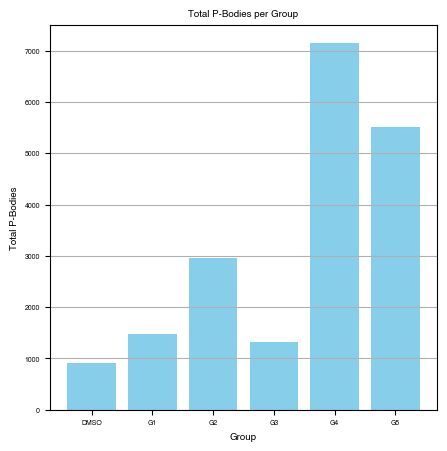

In [181]:
""" Boxplot creation: x-axis are count of pbodies and y-axis are groups. using group_summary dataframe (total_pbodies column) """
plt.figure(figsize=(5, 5))
plt.bar(group_summary['group'], group_summary['total_pbodies'], color='skyblue')
plt.xlabel('Group')
plt.ylabel('Total P-Bodies')
plt.title('Total P-Bodies per Group')
plt.xticks(group_summary['group'])
plt.grid(axis='y')
plt.show()

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/2166683291.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


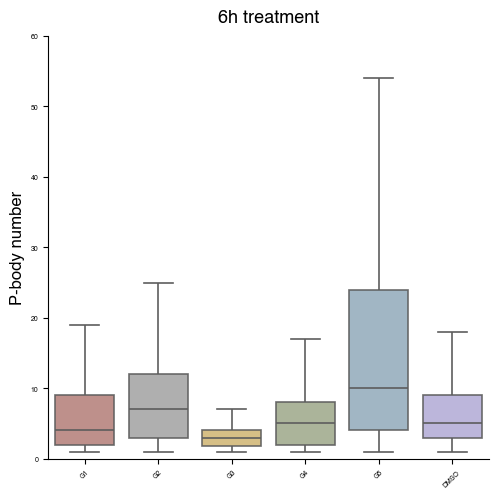

In [182]:
# --- reorder groups so DMSO is last ---
order = ["G1", "G2", "G3", "G4", "G5", "DMSO"]

# --- colors matching paper reference  ---
colors = ["#C17C74", "#A7A7A7", "#E1BE6A", "#A3B18A", "#90AFC5", "#B1A7DE"]

# --- plot ---
plt.figure(figsize=(5, 5))
sns.boxplot(
    x="group",
    y="pbody_number",
    data=combined_df,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)

# labels and aesthetics
plt.ylabel("P-body number", fontsize=12)
plt.xlabel("")
plt.title("6h treatment", fontsize=13, pad=10)
plt.xticks(rotation=45)
sns.despine()

# --- add significance stars manually (adjust y-coordinates to your data) ---
annotations = ["***", "ns", "***", "*", "***"]
# for i, (label, g) in enumerate(zip(annotations, order[:-1])):
#     plt.text(i, y_max + 1, label, ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.ylim(0, 60)
plt.tight_layout()
plt.show()


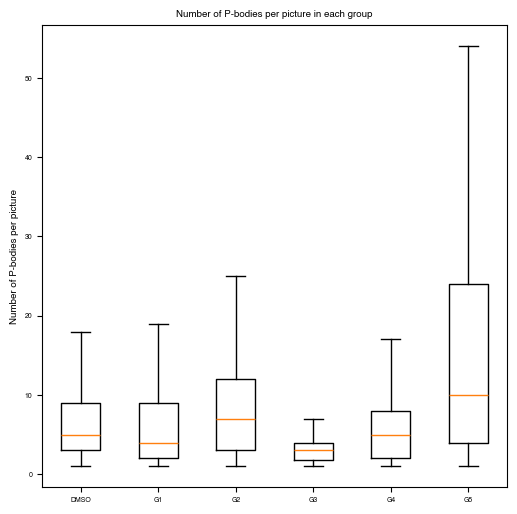

In [183]:
# Get unique group labels
groups = combined_df['group'].unique()

# Prepare data for each group
data_per_group = [
    combined_df.loc[combined_df['group'] == g, 'pbody_number'].values
    for g in groups
]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(data_per_group, tick_labels=groups, showfliers=False)
ax.set_ylabel('Number of P-bodies per picture')
ax.set_title('Number of P-bodies per picture in each group')
plt.show()


# Opening files to analyze2

In [184]:
""" Helper function to create a combined dataframe when given the group filepath"""
def create_combined_dataframe(group_filepath: str) -> pd.DataFrame:
    import os
    import glob

    # Get a list of all xlsx files in the specified directory
    files = glob.glob(os.path.join(group_filepath, "*.xlsx"))

    # Initialize an empty list to hold individual dataframes
    dataframes = []

    # Loop through each CSV file and read it into a dataframe
    for file in files:
        df = pd.read_excel(file)
        dataframes.append(df)

    # Concatenate all dataframes into a single dataframe
    combined_dataframe = pd.concat(dataframes, ignore_index=True)

    return combined_dataframe

## DMSO Group

In [185]:
""" Group 0 -> Test Data, open all files and put them in a dataframe """

dmso2  = create_combined_dataframe("dataset_t6_grouped/results2/G0")
dmso2.head(60)


""" Show only the highest "pbody_number" of the group 0 dataframe per image  """
dmso2_highest_pbopdy = dmso2.loc[dmso2.groupby('image')['pbody_number'].idxmax()]
dmso2_highest_pbopdy.tail(60)

,image,pbody_number,dist_nuclei,dist_mito,nuclei_std,mito_std,medicine,group
755,W0082F0002T0006Z000C1N151.png,17,20.880613,30.384852,18.100346,17.222821,DMSO,DMSO
682,W0082F0002T0006Z000C1N152.png,13,15.299378,17.473632,15.876156,15.711936,DMSO,DMSO
598,W0082F0002T0006Z000C1N153.png,4,21.533318,21.131255,19.315488,19.652796,DMSO,DMSO
398,W0082F0002T0006Z000C1N154.png,14,51.737919,52.118418,13.133963,13.181692,DMSO,DMSO
727,W0082F0002T0006Z000C1N156.png,9,14.849242,12.004629,13.239933,9.929465,DMSO,DMSO
958,W0082F0002T0006Z000C1N162.png,17,8.665700,8.049786,14.969031,19.157992,DMSO,DMSO
206,W0082F0002T0006Z000C1N19.png,11,69.664316,66.841092,12.406781,13.894365,DMSO,DMSO
888,W0082F0002T0006Z000C1N21.png,11,53.830977,55.641121,10.606353,10.408842,DMSO,DMSO
157,W0082F0002T0006Z000C1N30.png,9,63.240302,56.831418,9.398649,8.847658,DMSO,DMSO
1186,W0082F0002T0006Z000C1N35.png,27,9.980259,9.918280,11.809195,11.611562,DMSO,DMSO


## Group 1

In [186]:
""" Group 1 -> Test Data, open all files and put them in a dataframe """

g1_2  = create_combined_dataframe("dataset_t6_grouped/results2/G1")
# g1_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [187]:
""" check for nan values on g1 dataframe """
g1_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 2

In [188]:
""" Group 2 -> Test Data, open all files and put them in a dataframe """

g2_2  = create_combined_dataframe("dataset_t6_grouped/results2/G2")
# g2_2.head(50)


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [189]:
""" check for nan values on g2 dataframe """
g2_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 3

In [190]:
""" Group 3 -> Test Data, open all files and put them in a dataframe """

g3_2  = create_combined_dataframe("dataset_t6_grouped/results2/G3")
# g3_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [191]:
""" check for nan values on g3 dataframe """
g3_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 4

In [192]:
""" Group 4 -> Test Data, open all files and put them in a dataframe """

g4_2  = create_combined_dataframe("dataset_t6_grouped/results2/G4")
# g4_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [193]:
""" check for nan values on g4 dataframe """
g4_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 5

In [194]:
""" Group 5 -> Test Data, open all files and put them in a dataframe """

g5_2  = create_combined_dataframe("dataset_t6_grouped/results2/G5")
# g5_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [195]:
""" check for nan values on g1 dataframe """
g5_2.isna().sum()

image            0
pbody_number     0
dist_nuclei     84
dist_mito        0
nuclei_std      84
mito_std         0
medicine         0
group            0
dtype: int64

# Graphing Section 2

In [196]:
""" Create a function that stores pbody number on dataframe"""


def summarize_pbodies_by_group(*dataframes):
    """
     The original dataframes structure:
      ['image', 'pbody_number', 'dist_nuclei', 'dist_mito',
       'nuclei_std', 'mito_std', 'medicine', 'group']
    """

    # --- Combine all dataframes into one ---
    combined_df = pd.concat(dataframes, ignore_index=True)

    # --- Summary per group ---
    group_summary = (
        combined_df.groupby('group')
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'),
                        std_dist_nuclei=('dist_nuclei', 'std'),
                        std_dist_mito=('dist_mito', 'std'))
                   .reset_index()
    )

    # --- Summary per group and medicine ---
    med_summary = (
        combined_df.groupby(['group', 'medicine'])
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'))
                   .reset_index()
    )

    return group_summary, med_summary, combined_df

In [197]:
""" Calling function for each dataframe """
group_summary_2, med_summary_2, combined_df_2 = summarize_pbodies_by_group(dmso2, g1_2, g2_2, g3_2, g4_2, g5_2)
group_summary_2.head(10)

,group,total_pbodies,mean_dist_nuclei,mean_dist_mito,std_dist_nuclei,std_dist_mito
0,DMSO,1187,36.521099,33.031702,17.231444,16.779011
1,G1,1766,31.719852,28.287695,16.734257,15.708912
2,G2,3478,34.345958,33.123843,17.875323,17.451118
3,G3,1467,41.809980,39.340835,21.278405,21.372156
4,G4,8612,37.125599,33.331698,18.560670,18.352796
5,G5,5409,38.296497,32.111656,25.102401,23.058378


In [198]:
med_summary_2.head(10)

,group,medicine,total_pbodies,mean_dist_nuclei,mean_dist_mito
0,DMSO,DMSO,1187,36.521099,33.031702
1,G1,T0374,197,28.942662,28.894720
2,G1,T0374L,225,27.804494,29.433554
3,G1,T1912,208,30.240911,28.080293
4,G1,T1995,201,30.070255,28.453171
5,G1,T6020,165,32.303654,26.460821
6,G1,T7394,770,34.279494,28.201866
7,G2,T0860,590,33.286611,31.873598
8,G2,T1448,713,33.687435,32.221733
9,G2,T1656,471,34.478767,32.868664


In [199]:
combined_df_2.head(10)

# combined_df_2 = combined_df_2[combined_df_2['group'] == "G5"]
# combined_df_2

,image,pbody_number,dist_nuclei,dist_mito,nuclei_std,mito_std,medicine,group
0,W0082F0003T0006Z000C1N39.png,1,43.387036,52.802165,6.095940,7.435404,DMSO,DMSO
1,W0082F0003T0006Z000C1N39.png,2,49.414322,49.487081,6.095940,7.435404,DMSO,DMSO
2,W0082F0003T0006Z000C1N39.png,3,32.170167,32.546218,6.095940,7.435404,DMSO,DMSO
3,W0082F0003T0006Z000C1N39.png,4,46.954513,47.424503,6.095940,7.435404,DMSO,DMSO
4,W0082F0003T0006Z000C1N39.png,5,39.175751,38.882883,6.095940,7.435404,DMSO,DMSO
5,W0082F0002T0006Z000C1N4.png,1,39.020949,39.589909,6.949193,7.089028,DMSO,DMSO
6,W0082F0002T0006Z000C1N4.png,2,38.122005,38.374374,6.949193,7.089028,DMSO,DMSO
7,W0082F0002T0006Z000C1N4.png,3,36.238307,36.182783,6.949193,7.089028,DMSO,DMSO
8,W0082F0002T0006Z000C1N4.png,4,39.916233,39.611842,6.949193,7.089028,DMSO,DMSO
9,W0082F0002T0006Z000C1N4.png,5,25.077216,24.652288,6.949193,7.089028,DMSO,DMSO


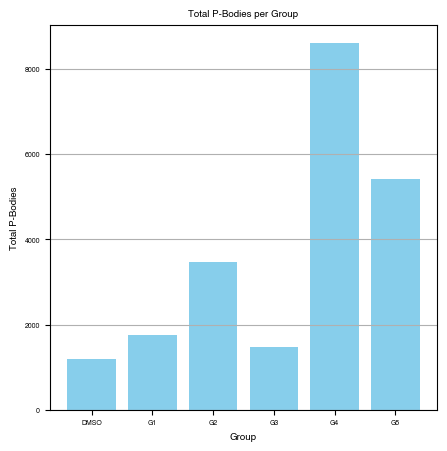

In [200]:
""" Boxplot creation: x-axis are count of pbodies and y-axis are groups. using group_summary dataframe (total_pbodies column) """
plt.figure(figsize=(5, 5))
plt.bar(group_summary_2['group'], group_summary_2['total_pbodies'], color='skyblue')
plt.xlabel('Group')
plt.ylabel('Total P-Bodies')
plt.title('Total P-Bodies per Group')
plt.xticks(group_summary_2['group'])
plt.grid(axis='y')
plt.show()

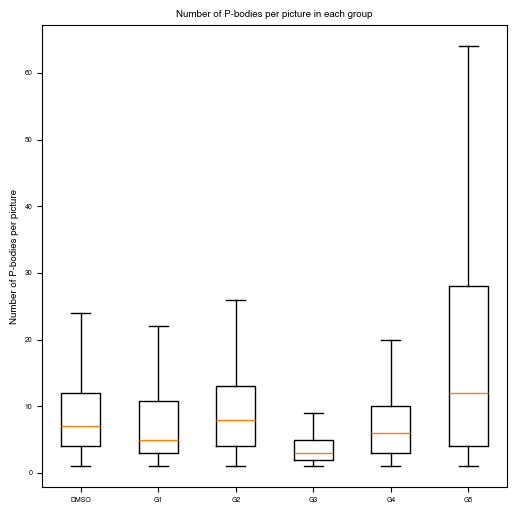

In [201]:
# Get unique group labels
groups = combined_df_2['group'].unique()

# Prepare data for each group
data_per_group_2 = [
    combined_df_2.loc[combined_df_2['group'] == g, 'pbody_number'].values
    for g in groups
]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(data_per_group_2, tick_labels=groups, showfliers=False)
ax.set_ylabel('Number of P-bodies per picture')
ax.set_title('Number of P-bodies per picture in each group')
plt.show()


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/2770044040.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


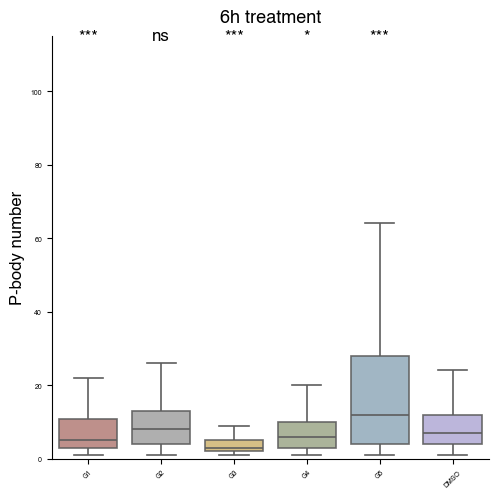

In [202]:
# --- reorder groups so DMSO is last ---
order = ["G1", "G2", "G3", "G4", "G5", "DMSO"]

# --- colors matching paper reference  ---
colors = ["#C17C74", "#A7A7A7", "#E1BE6A", "#A3B18A", "#90AFC5", "#B1A7DE"]

# --- plot ---
plt.figure(figsize=(5, 5))
sns.boxplot(
    x="group",
    y="pbody_number",
    data=combined_df_2,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)

# labels and aesthetics
plt.ylabel("P-body number", fontsize=12)
plt.xlabel("")
plt.title("6h treatment", fontsize=13, pad=10)
plt.xticks(rotation=45)
sns.despine()

# --- add significance stars manually (adjust y-coordinates to your data) ---
annotations = ["***", "ns", "***", "*", "***"]
y_max = combined_df_2["pbody_number"].max()
for i, (label, g) in enumerate(zip(annotations, order[:-1])):
    plt.text(i, y_max + 1, label, ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.ylim(0, y_max + 3)
plt.tight_layout()
plt.show()


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/1692681138.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


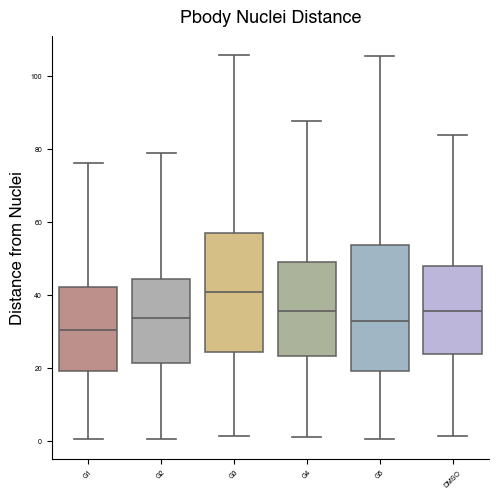

In [203]:
""" 
    Create A boxplot that shows the mean distance from nuclei per picture in each group using the combined_df_2 table
"""
plt.figure(figsize=(5, 5))
sns.boxplot(
    x="group",
    y="dist_nuclei",
    data=combined_df_2,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)
# labels and aesthetics
plt.ylabel("Distance from Nuclei", fontsize=12)
plt.xlabel("")
plt.title("Pbody Nuclei Distance", fontsize=13, pad=10)
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()


# --- plot ---

In [204]:
import matplotlib.font_manager as fm
for f in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if "Helvetica" in f:
        print(f)


/System/Library/Fonts/Helvetica.ttc
/System/Library/Fonts/HelveticaNeue.ttc


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/357611048.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


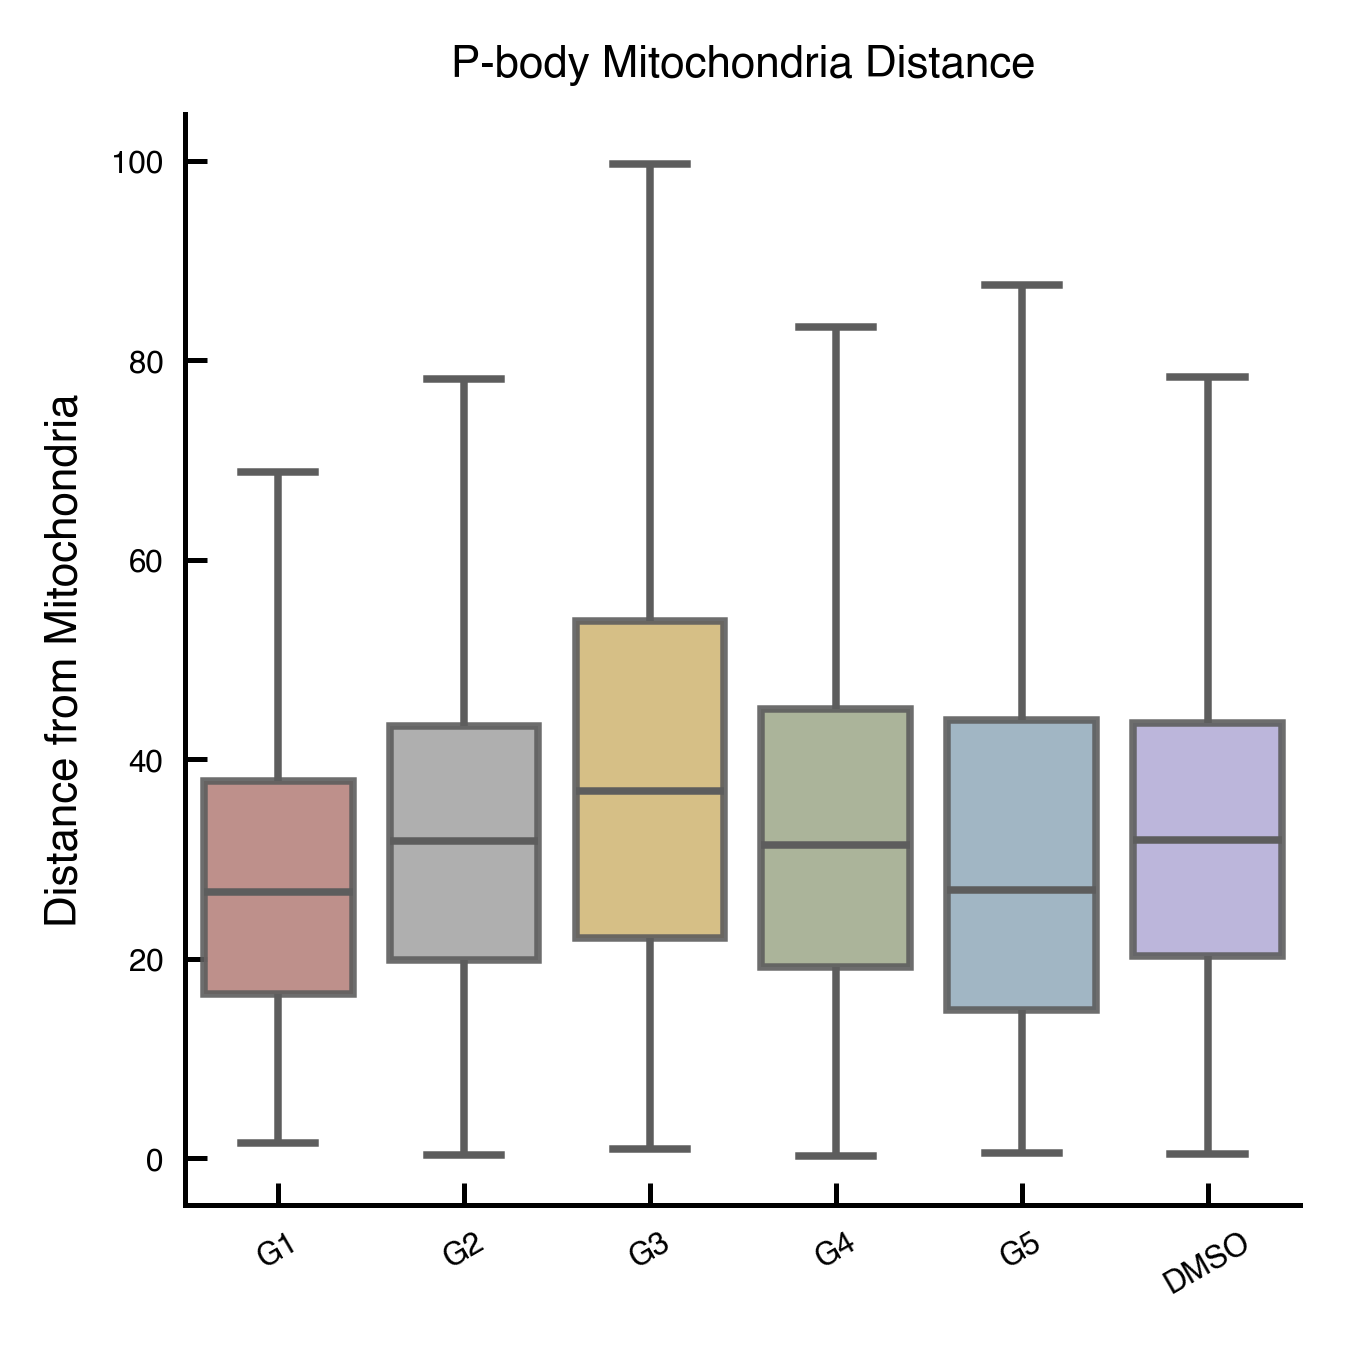

In [205]:
"""
    Create a boxplot that shows the mean distance from mitochondria per picture in each group using the combined_df_2 table 
"""

# --- Set Helvetica globally ---
helvetica_path = "/System/Library/Fonts/Helvetica.ttc"
helvetica = fm.FontProperties(fname=helvetica_path)
plt.rcParams['font.family'] = helvetica.get_name()
plt.rcParams["axes.labelsize"] = 7
plt.rcParams["xtick.labelsize"] = 5
plt.rcParams["ytick.labelsize"] = 5
plt.rcParams["axes.titlesize"] = 7


plt.figure(figsize=(3, 3), dpi=450)
sns.boxplot(
    x="group",
    y="dist_mito",
    data=combined_df_2,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)
# Labels
plt.ylabel("Distance from Mitochondria", fontsize=7)
plt.xlabel("")

# Title
plt.title("P-body Mitochondria Distance", fontsize=7, pad=6)

# Ticks
plt.xticks(rotation=30, fontsize=5)
plt.yticks(fontsize=5)
plt.tick_params(direction='in')

# Clean style
sns.despine()

plt.tight_layout()
plt.savefig("pbody_mito_distance_boxplot.png", dpi=450)
plt.show()

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/3731558580.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


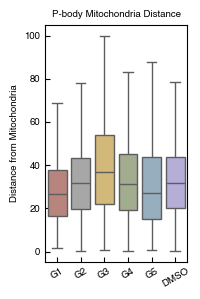

In [206]:
"""
    Create a boxplot that shows the mean distance from mitochondria per picture in each group
    using the combined_df_2 table — styled to match the 6h-treatment figure
"""

# --- Set Helvetica globally ---
helvetica_path = "/System/Library/Fonts/Helvetica.ttc"
helvetica = fm.FontProperties(fname=helvetica_path)
plt.rcParams['font.family'] = helvetica.get_name()

plt.figure(figsize=(2, 3))

sns.boxplot(
    data=combined_df_2,
    x="group",
    y="dist_mito",
    order=order,
    palette=colors,
    showfliers=False
)

# Labels and Title
plt.ylabel("Distance from Mitochondria", fontsize=7)
plt.xlabel("", fontsize=7)
plt.title("P-body Mitochondria Distance", fontsize=7)

# Ticks
plt.xticks(rotation=30, fontsize=7)
plt.yticks(fontsize=7)
plt.tick_params(direction='in')


plt.tight_layout()
plt.savefig("pbody_mito_distance_boxplot.png", dpi=450)
plt.show()


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/2188801629.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


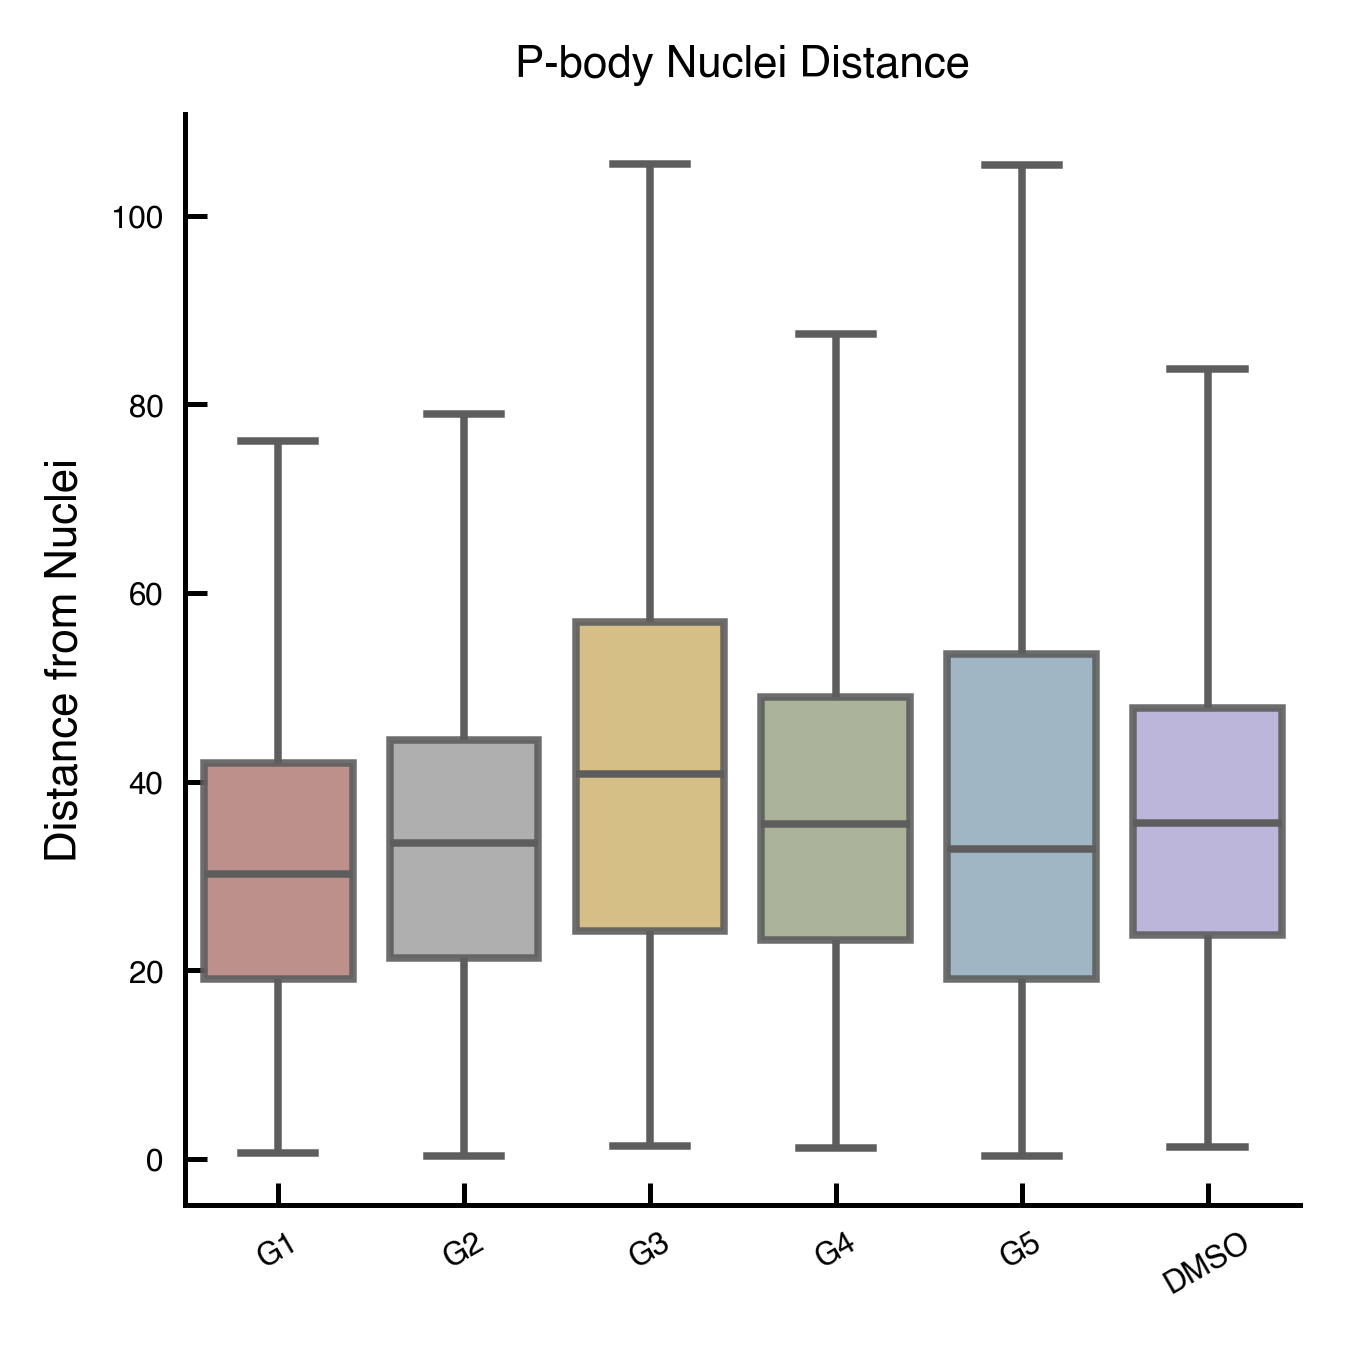

In [207]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Set Helvetica globally ---
helvetica_path = "/System/Library/Fonts/Helvetica.ttc"
helvetica = fm.FontProperties(fname=helvetica_path)
plt.rcParams['font.family'] = helvetica.get_name()
plt.rcParams["axes.labelsize"] = 7
plt.rcParams["xtick.labelsize"] = 5
plt.rcParams["ytick.labelsize"] = 5
plt.rcParams["axes.titlesize"] = 7

# --- Plot ---
plt.figure(figsize=(3, 3), dpi=450)

sns.boxplot(
    x="group",
    y="dist_nuclei",
    data=combined_df_2,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)

# Labels
plt.ylabel("Distance from Nuclei", fontsize=7)
plt.xlabel("")

# Title
plt.title("P-body Nuclei Distance", fontsize=7, pad=6)

# Ticks
plt.xticks(rotation=30, fontsize=5)
plt.yticks(fontsize=5)
plt.tick_params(direction='in')

# Clean style
sns.despine()

plt.tight_layout()
plt.savefig("pbody_nuclei_distance_boxplot.png", dpi=450)
plt.show()


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/3386583171.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


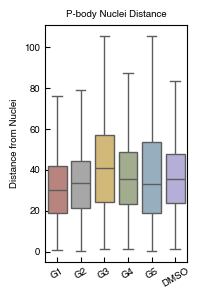

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

"""
    Create a boxplot that shows the mean distance from nuclei per picture in each group
    using the combined_df_2 table — styled to match the 6h-treatment figure
"""

# --- Set Helvetica globally ---
helvetica_path = "/System/Library/Fonts/Helvetica.ttc"
helvetica = fm.FontProperties(fname=helvetica_path)
plt.rcParams['font.family'] = helvetica.get_name()

# --- Plot ---
plt.figure(figsize=(2, 3))

sns.boxplot(
    data=combined_df_2,
    x="group",
    y="dist_nuclei",
    order=order,
    palette=colors,
    showfliers=False
)

# Labels
plt.ylabel("Distance from Nuclei", fontsize=7)
plt.xlabel("", fontsize=7)
plt.tick_params(direction='in')


# Title
plt.title("P-body Nuclei Distance", fontsize=7)

# Ticks
plt.xticks(rotation=30, fontsize=7)
plt.yticks(fontsize=7)

plt.tight_layout()
plt.savefig("pbody_nuclei_distance_boxplot.png", dpi=450)
plt.show()


In [209]:
from scipy.stats import mannwhitneyu
import pandas as pd

def mann_whitney_tests(combined_df: pd.DataFrame, groups: list, control_group: str = "DMSO"):
    results = []

    # Correct: use combined_df, not combined_df_2
    control_data_nuclei = combined_df.loc[combined_df['group'] == control_group, 'dist_nuclei']
    control_data_mito = combined_df.loc[combined_df['group'] == control_group, 'dist_mito']

    for group in groups:
        if group == control_group:
            continue

        group_data_nuclei = combined_df.loc[combined_df['group'] == group, 'dist_nuclei']
        group_data_mito = combined_df.loc[combined_df['group'] == group, 'dist_mito']

        # Mann-Whitney U test
        stat_nuclei, p_value_nuclei = mannwhitneyu(
            group_data_nuclei, control_data_nuclei, alternative='two-sided'
        )
        stat_mito, p_value_mito = mannwhitneyu(
            group_data_mito, control_data_mito, alternative='two-sided'
        )

        results.append({
            'group': group,
            'nuclei_stat': stat_nuclei,
            'nuclei_p_value': p_value_nuclei,
            'mito_stat': stat_mito,
            'mito_p_value': p_value_mito
        })

    return pd.DataFrame(results)

# take away nan from combined_df_2
combined_df_2 = combined_df_2.dropna(subset=['dist_nuclei', 'dist_mito'])

mann_whitney_tests(combined_df_2, order)

,group,nuclei_stat,nuclei_p_value,mito_stat,mito_p_value
0,G1,873949.5,1.757016e-14,871233.5,6.871236e-15
1,G2,1892382.0,1.801046e-05,2059554.0,9.078328e-01
2,G3,986415.5,3.698749e-09,1007091.5,3.639676e-12
3,G4,5142125.0,7.352006e-01,5082040.0,7.494383e-01
4,G5,3075877.5,1.490634e-01,2878239.5,1.456155e-06


In [210]:
combined_df_2[combined_df_2["group"] == "G5"].isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

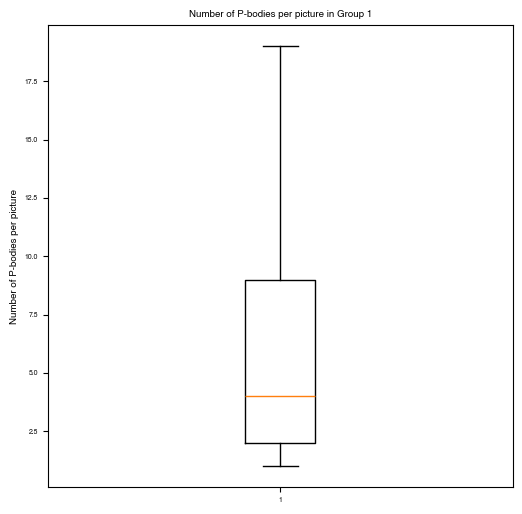

In [211]:
"""
    Graphing the number of pbodies by picture in group 1 using boxplot
"""

group_1_data = combined_df[combined_df['group'] == 'G1']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_1_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group 1')
plt.show()


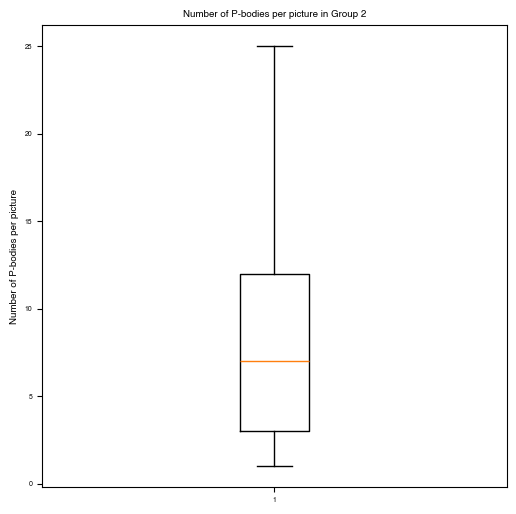

In [212]:
"""
    Graphing the number of pbodies by picture in group 2 using boxplot
"""

group_2_data = combined_df[combined_df['group'] == 'G2']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_2_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group 2')
plt.show()

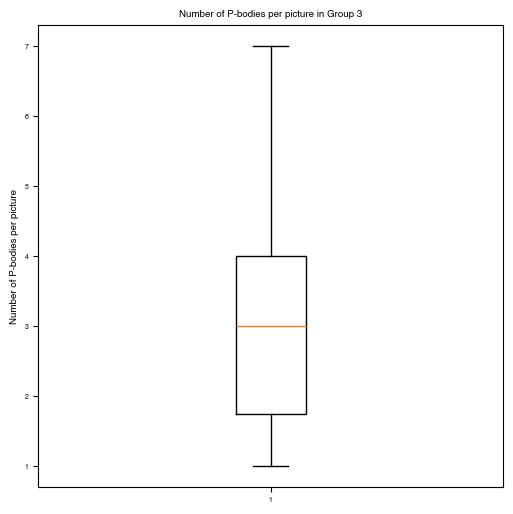

In [213]:
"""
    Graphing the number of pbodies by picture in group 3 using boxplot
"""

group_3_data = combined_df[combined_df['group'] == 'G3']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_3_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group 3')
plt.show()

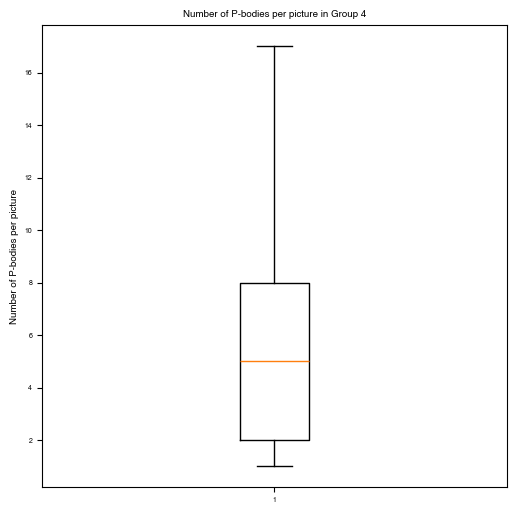

In [214]:
"""
    Graphing the number of pbodies by picture in group 4 using boxplot
"""

group_4_data = combined_df[combined_df['group'] == 'G4']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_4_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group 4')
plt.show()

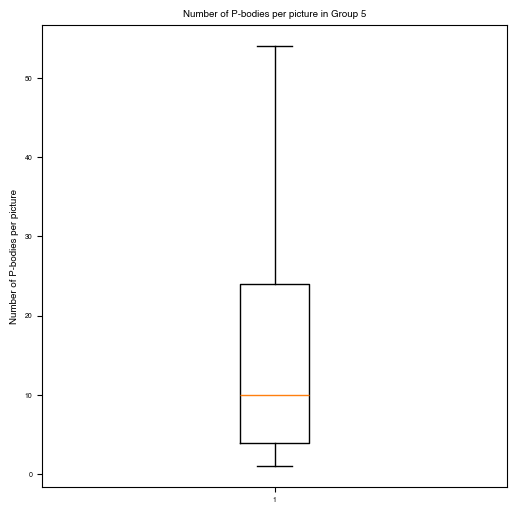

In [215]:
"""
    Graphing the number of pbodies by picture in group 4 using boxplot
"""

group_5_data = combined_df[combined_df['group'] == 'G5']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_5_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group 5')
plt.show()

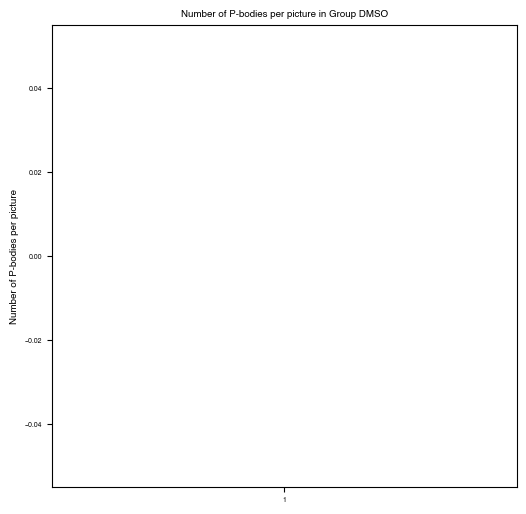

In [216]:
"""
    Graphing the number of pbodies by picture in group 0 using boxplot
"""

group_0_data = combined_df[combined_df['group'] == 'dmso']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_0_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group DMSO')
plt.show()

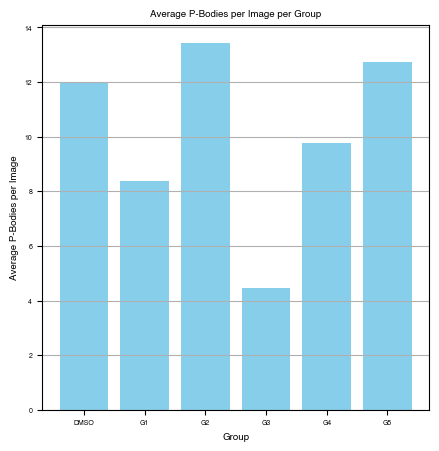

In [217]:
"""
    Boxplot of pbodies per group, calculated using the combined_df_2 dataframe and ensuring the average is calculated based on total pbody/number of images in each group
"""

# Calculate number of images per group
image_counts = combined_df_2.groupby('group')['image'].nunique().reset_index()
image_counts.columns = ['group', 'num_images']
# Merge image counts with group summary
group_summary_2 = group_summary_2.merge(image_counts, on='group')
# Calculate average pbodies per image
group_summary_2['avg_pbodies_per_image'] = group_summary_2['total_pbodies'] / group_summary_2['num_images']
# Boxplot creation
plt.figure(figsize=(5, 5))
plt.bar(group_summary_2['group'], group_summary_2['avg_pbodies_per_image'], color='skyblue')
plt.xlabel('Group')
plt.ylabel('Average P-Bodies per Image')
plt.title('Average P-Bodies per Image per Group')
plt.xticks(group_summary_2['group'])
plt.grid(axis='y')
plt.show()


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_99097/3215847997.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=group_labels, showfliers=False)


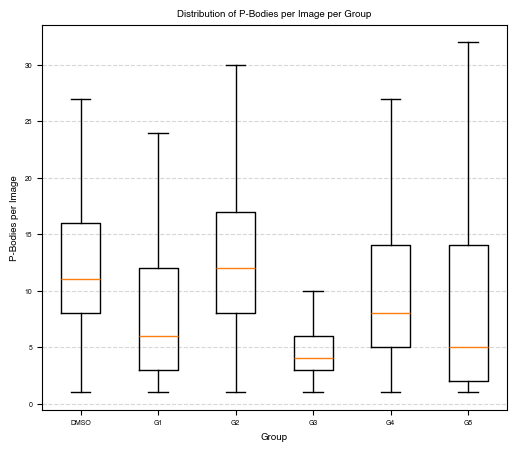

In [218]:
"""
    Boxplot of average pbodies per image in each group.
"""

# 1. Count pbodies per image
pbodies_per_image = (
    combined_df_2
    .groupby(['group', 'image'])['pbody_number']
    .count()
    .reset_index()
    .rename(columns={'pbody_number': 'pbodies_in_image'})
)

# 2. Create boxplot data structure
boxplot_data = [
    pbodies_per_image.loc[pbodies_per_image['group'] == g, 'pbodies_in_image'].values
    for g in sorted(pbodies_per_image['group'].unique())
]

group_labels = sorted(pbodies_per_image['group'].unique())

# 3. Plot boxplot
plt.figure(figsize=(6, 5))
plt.boxplot(boxplot_data, labels=group_labels, showfliers=False)

plt.xlabel('Group')
plt.ylabel('P-Bodies per Image')
plt.title('Distribution of P-Bodies per Image per Group')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [219]:
"""
    Create function to download all figures as pdf based on their saved filename on plt
"""
def save_figure_as_pdf(figure_filename, pdf_filename):
    """ Save a figure as PDF.
    
    Args:
        figure_filename (str): The filename of the figure to load (e.g., PNG).
        pdf_filename (str): The desired PDF filename to save.
    """
    from matplotlib.backends.backend_pdf import PdfPages
    from PIL import Image

    # Load the image
    img = Image.open(figure_filename)

    # Create a PDF
    with PdfPages(pdf_filename) as pdf:
        fig, ax = plt.subplots(figsize=(img.width / 100, img.height / 100), dpi=100)
        ax.imshow(img)
        ax.axis('off')  # No axes for image
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        
# Calling function to save plots:
save_figure_as_pdf("pbody_mito_distance_boxplot.png", "pbody_mito_distance_boxplot.pdf")
save_figure_as_pdf("pbody_nuclei_distance_boxplot.png", "pbody_nuclei_distance_boxplot.pdf")